# Лабораторная работа 10

Тема: **Рекуррентные сети (LSTM/GRU) для классификации текстов в PyTorch**  
Цель: реализовать полный цикл решения задачи бинарной классификации текстов с помощью LSTM‑модели: от токенизации и построения словаря до обучения, валидации и анализа ошибок.

> Этот ноутбук оформлен как практическое задание.  
> Код даёт каркас, но основная часть баллов — за ваши собственные эксперименты и ваши пояснения.  
> Если вы попытаетесь автоматически сгенерировать весь текст отчёта, это будет заметно по стилю и несоответствию реальным графикам и числам.


## 1. Ваше исходное понимание задачи (обязательная текстовая часть)

Перед запуском кода зафиксируйте свои текущие представления (6–10 предложений):

1. Чем классификация текстов отличается от задач на изображения и табличные данные, с которыми вы уже работали.  
2. Зачем в текстовых задачах использовать рекуррентные сети (LSTM/GRU), а не просто среднее эмбеддингов слов с подачей в MLP.  
3. Как вы ожидаете, что **длина** текста и **порядок слов** повлияют на качество модели.

Пишите на своём языке, без попытки сделать "идеальное определение".


In [8]:
intro_text = """
1) Текст отличается от картинок и таблиц тем, что данные идут последовательно и порядок важен. В таблице признаки независимы в картинке есть пространственная структура, а в тексте смысл формируется через цепочку слов. Нельзя просто взять все слова и скормить их в MLP — потеряется контекст.

2) Если просто усреднить эмбеддинги слов и подать в MLP, то модель не будет знать в каком порядке шли слова. Для тональности это критично — not bad и bad not по сути дадут одинаковый средний вектор, но смысл разный. LSTM запоминает состояние по ходу чтения и может учитывать такие зависимости.

3) Длина текста влияет сильно — очень длинные тексты LSTM может плохо запомнить из за затухающих градиентов. Порядок слов важен для понимания отрицаний и контекста. На коротких текстах модель должна работать лучше, на длинных хуже.
"""
print(intro_text)


1) Текст отличается от картинок и таблиц тем, что данные идут последовательно и порядок важен. В таблице признаки независимы в картинке есть пространственная структура, а в тексте смысл формируется через цепочку слов. Нельзя просто взять все слова и скормить их в MLP — потеряется контекст.

2) Если просто усреднить эмбеддинги слов и подать в MLP, то модель не будет знать в каком порядке шли слова. Для тональности это критично — not bad и bad not по сути дадут одинаковый средний вектор, но смысл разный. LSTM запоминает состояние по ходу чтения и может учитывать такие зависимости.

3) Длина текста влияет сильно — очень длинные тексты LSTM может плохо запомнить из за затухающих градиентов. Порядок слов важен для понимания отрицаний и контекста. На коротких текстах модель должна работать лучше, на длинных хуже.



## 2. Импорт библиотек и настройка среды

Загрузим необходимые библиотеки, зафиксируем зерно случайности и определим устройство (`cpu` или `cuda`).


In [9]:
import re
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

MY_SEED = 42
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 42


## 3. Пример простого текстового датасета

Для примера используем небольшой игрушечный датасет коротких предложений на английском с метками `0/1` (негатив/позитив).  
В **своей** лабораторной вы должны будете взять более содержательный и шумный датасет (реальные отзывы, комментарии и т.п.) - выберите какой-нибудь объект (фильм на кинопоиске, товар на озоне/вб, заведение на яндекс картах), скопируйте о нем отзывы, переведите на английский, раскидайте по  двум классам. Свой датасет соберите в отдельной новой ячейке.


In [10]:
positive_sentences = [
    "I really liked this movie",
    "This film was great and inspiring",
    "What a fantastic experience",
    "I enjoyed every minute of it",
    "The actors did an amazing job",
    "Brilliant story and good pacing",
    "I would definitely watch it again",
    "It was funny and heartwarming",
    "A very beautiful and touching film",
    "Absolutely loved the characters"
]

negative_sentences = [
    "I really hated this movie",
    "This film was boring and slow",
    "What a terrible experience",
    "I regretted every minute of it",
    "The actors did a very bad job",
    "Awful story and strange pacing",
    "I would never watch it again",
    "It was dull and annoying",
    "A very ugly and pointless film",
    "Absolutely disliked the characters"
]

texts = positive_sentences + negative_sentences
labels = [1] * len(positive_sentences) + [0] * len(negative_sentences)

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(df.head())
print("Размер датасета:", df.shape)
print("Распределение классов:\n", df["label"].value_counts())

                                 text  label
0           I really liked this movie      1
1            It was dull and annoying      0
2      Awful story and strange pacing      0
3   This film was great and inspiring      1
4  A very beautiful and touching film      1
Размер датасета: (20, 2)
Распределение классов:
 label
1    10
0    10
Name: count, dtype: int64


### Ваши замечания по датасету (обязательная мини‑секция)

Опишите (3–5 предложений):
- насколько базовый набор похож/не похож на реальные отзывы;  
- какие особенности реальных текстов в нем отсутствуют (длина, сленг, опечатки, смешение языков и т.п.);
- как эти отличия могут повлиять на результаты модели.


In [11]:
data_comment = """
Игрушечный датасет очень простой и искусственный — предложения короткие, структура симметричная, слова почти не повторяются между классами.
В реальных отзывах всё сложнее: тексты длиннее возможно есть сарказм, опечатки, смешение языков, неоднозначные оценки типа "в целом норм но концовка плохая.

На таком датасете модель легко выучит паттерны, но это не значит что она справится с реальными данными — там придётся иметь дело с гораздо большим словарём и шумом.
"""
print(data_comment)


Игрушечный датасет очень простой и искусственный — предложения короткие, структура симметричная, слова почти не повторяются между классами.
В реальных отзывах всё сложнее: тексты длиннее возможно есть сарказм, опечатки, смешение языков, неоднозначные оценки типа "в целом норм но концовка плохая.

На таком датасете модель легко выучит паттерны, но это не значит что она справится с реальными данными — там придётся иметь дело с гораздо большим словарём и шумом.



## 4. Токенизация, словарь и паддинг

Сделаем простую токенизацию:
- приведём текст к нижнему регистру;
- удалим лишние символы;
- разобьём строку на токены по пробелам.

Затем построим словарь и приведём все последовательности к одинаковой длине `max_len` с помощью паддинга.


In [12]:
def simple_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    return tokens

df["tokens"] = df["text"].apply(simple_tokenize)
print(df[["text", "tokens"]].head())

                                 text  \
0           I really liked this movie   
1            It was dull and annoying   
2      Awful story and strange pacing   
3   This film was great and inspiring   
4  A very beautiful and touching film   

                                      tokens  
0            [i, really, liked, this, movie]  
1             [it, was, dull, and, annoying]  
2       [awful, story, and, strange, pacing]  
3   [this, film, was, great, and, inspiring]  
4  [a, very, beautiful, and, touching, film]  


In [13]:
# Подсчёт частот слов и построение словаря
word_counts = {}
for tokens in df["tokens"]:
    for w in tokens:
        word_counts[w] = word_counts.get(w, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in sorted_words:
    word2idx[w] = len(word2idx)

idx2word = {idx: w for w, idx in word2idx.items()}

print("Размер словаря:", len(word2idx))
print("Первые элементы словаря:", list(word2idx.items())[:10])

Размер словаря: 57
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('and', 2), ('i', 3), ('it', 4), ('a', 5), ('this', 6), ('was', 7), ('film', 8), ('the', 9)]


In [14]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

df["encoded"] = df["tokens"].apply(lambda t: encode_tokens(t, word2idx))
print(df[["tokens", "encoded"]].head())

lengths = df["encoded"].apply(len)
print("Мин и макс длины последовательностей:", lengths.min(), lengths.max())
max_len = int(lengths.max())  # для примера берём максимум
print("max_len =", max_len)

                                      tokens                encoded
0            [i, really, liked, this, movie]     [3, 11, 28, 6, 12]
1             [it, was, dull, and, annoying]      [4, 7, 29, 2, 30]
2       [awful, story, and, strange, pacing]    [31, 13, 2, 32, 14]
3   [this, film, was, great, and, inspiring]   [6, 8, 7, 33, 2, 34]
4  [a, very, beautiful, and, touching, film]  [5, 10, 35, 2, 36, 8]
Мин и макс длины последовательностей: 4 7
max_len = 7


In [15]:
def pad_sequence(seq, max_len, pad_idx=0):
    if len(seq) < max_len:
        return seq + [pad_idx] * (max_len - len(seq))
    else:
        return seq[:max_len]

df["padded"] = df["encoded"].apply(lambda s: pad_sequence(s, max_len, pad_idx=word2idx["<PAD>"]))
print(df[["encoded", "padded"]].head())

                 encoded                     padded
0     [3, 11, 28, 6, 12]   [3, 11, 28, 6, 12, 0, 0]
1      [4, 7, 29, 2, 30]    [4, 7, 29, 2, 30, 0, 0]
2    [31, 13, 2, 32, 14]  [31, 13, 2, 32, 14, 0, 0]
3   [6, 8, 7, 33, 2, 34]    [6, 8, 7, 33, 2, 34, 0]
4  [5, 10, 35, 2, 36, 8]   [5, 10, 35, 2, 36, 8, 0]


### Мини‑вопрос

Ответьте коротко (2–4 предложения):
- какие последствия, по вашему мнению, будет иметь **слишком маленький** `max_len` на реальном датасете;  
- и какие - очень **большой** `max_len` (для обучения и оценки).


In [16]:
padding_comment = """
Если max_len слишком маленький — часть текста просто обрежется и модель не увидит конец предложения, где часто бывает важная информация.
Если max_len очень большой — большинство коротких текстов будут с огромным хвостом из нулей-паддингов, это замедляет обучение и может мешать модели, хотя padding_idx в Embedding частично это решает.
"""
print(padding_comment)


Если max_len слишком маленький — часть текста просто обрежется и модель не увидит конец предложения, где часто бывает важная информация.
Если max_len очень большой — большинство коротких текстов будут с огромным хвостом из нулей-паддингов, это замедляет обучение и может мешать модели, хотя padding_idx в Embedding частично это решает.



## 5. Разбиение на train/val/test и Dataset/DataLoader

Разобьём примеры на три части и подготовим `Dataset`/`DataLoader`.


In [17]:
X = np.stack(df["padded"].values)
y = df["label"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=MY_SEED, stratify=y_temp
)

print("Размеры:")
print("  train:", X_train.shape)
print("  val  :", X_val.shape)
print("  test :", X_test.shape)

Размеры:
  train: (12, 7)
  val  : (4, 7)
  test : (4, 7)


In [18]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))


Кол-во батчей в train_loader: 2


## 6. Модель: Embedding + LSTM + классификатор

Опишем базовую архитектуру:
- слой `Embedding` для кодирования токенов;
- один слой LSTM (можете заменить на GRU в своих экспериментах);
- полносвязный выход на 2 логита (для классов 0/1).


In [19]:
vocab_size = len(word2idx)
embed_dim = 32
hidden_dim = 64
num_layers = 1
num_classes = 2

class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)              # [B, T] -> [B, T, E]
        output, (h_n, c_n) = self.lstm(emb)  # h_n: [L, B, H]
        last_hidden = h_n[-1]                # [B, H] — последнее по времени состояние верхнего слоя
        logits = self.fc(last_hidden)
        return logits

model = SimpleLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=word2idx["<PAD>"]
).to(device)

print(model)

SimpleLSTMClassifier(
  (embedding): Embedding(57, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


### Краткий комментарий по архитектуре

Ответьте в 3–5 предложениях:
- почему вы считаете, что такой размер эмбеддингов и скрытого слоя **достаточен/недостаточен** для этого игрушечного примера;  
- какие изменения архитектуры вы бы первыми попробовали при переходе к реальному датасету.


In [20]:
arch_comment = """
Для игрушечного датасета из 20 коротких предложений embed_dim=32 и hidden_dim=64 более чем достаточно — там буквально пара десятков уникальных слов.
На реальном датасете с большим словарём я бы первым делом увеличил embed_dim до 64-128 и hidden_dim до 128-256. Также стоит попробовать два слоя LSTM и добавить Dropout между ними — на реальных данных переобучение будет заметнее.
"""
print(arch_comment)


Для игрушечного датасета из 20 коротких предложений embed_dim=32 и hidden_dim=64 более чем достаточно — там буквально пара десятков уникальных слов.
На реальном датасете с большим словарём я бы первым делом увеличил embed_dim до 64-128 и hidden_dim до 128-256. Также стоит попробовать два слоя LSTM и добавить Dropout между ними — на реальных данных переобучение будет заметнее.



## 7. Функция потерь, оптимизатор и цикл обучения

Используем `CrossEntropyLoss` и `Adam`.  
Реализуем функции `train_one_epoch` и `evaluate`, затем запустим обучение.


In [21]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [22]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [23]:
num_epochs = 25
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/25: train_loss=0.6932, train_acc=0.5000, val_loss=0.6877, val_acc=0.5000
Эпоха 2/25: train_loss=0.6864, train_acc=0.5833, val_loss=0.6903, val_acc=0.5000
Эпоха 3/25: train_loss=0.6822, train_acc=0.6667, val_loss=0.6934, val_acc=0.5000
Эпоха 4/25: train_loss=0.6790, train_acc=0.6667, val_loss=0.6965, val_acc=0.5000
Эпоха 5/25: train_loss=0.6749, train_acc=0.6667, val_loss=0.6993, val_acc=0.5000
Эпоха 6/25: train_loss=0.6720, train_acc=0.6667, val_loss=0.7025, val_acc=0.5000
Эпоха 7/25: train_loss=0.6689, train_acc=0.5833, val_loss=0.7056, val_acc=0.5000
Эпоха 8/25: train_loss=0.6644, train_acc=0.6667, val_loss=0.7087, val_acc=0.2500
Эпоха 9/25: train_loss=0.6598, train_acc=0.6667, val_loss=0.7122, val_acc=0.2500
Эпоха 10/25: train_loss=0.6547, train_acc=0.6667, val_loss=0.7161, val_acc=0.2500
Эпоха 11/25: train_loss=0.6492, train_acc=0.6667, val_loss=0.7210, val_acc=0.2500
Эпоха 12/25: train_loss=0.6445, train_acc=0.6667, val_loss=0.7264, val_acc=0.2500
Эпоха 13/25: train_loss=0

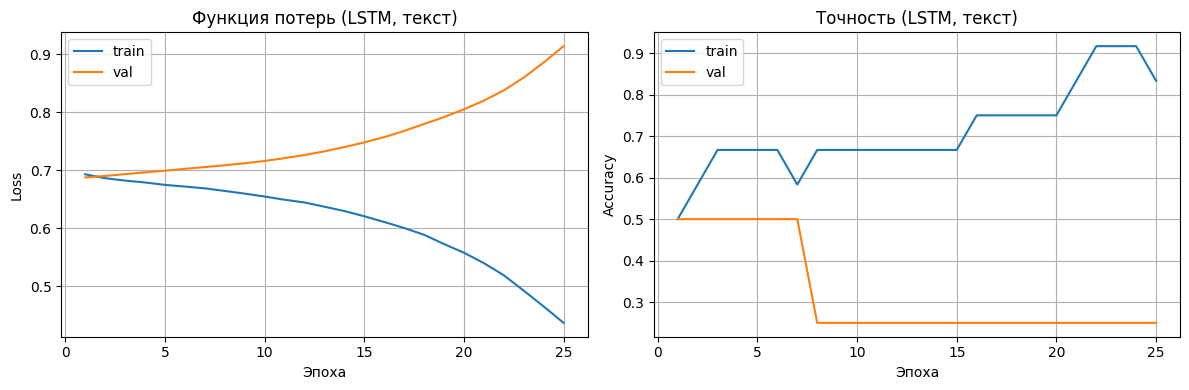

Финальные метрики: train_acc=0.8333, val_acc=0.2500


In [24]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальные метрики: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- что происходит с точностью на **валидации**;
- есть ли заметный разрыв между train и val;
- что вы ожидаете увидеть на реальных данных при тех же настройках.


In [25]:
training_comment = """На первых 7 эпохах val_acc держалась на 0.5, train_acc был в районе 0.5-0.67. С 8-й эпохи val_acc резко упал до 0.25 и там застрял — модель перестала обобщать.

Train_acc при этом продолжал расти и к 22-й эпохе дошёл до 0.9167. Финал: train_acc=0.8333, val_acc=0.2500.

Это сильное переобучение — модель запомнила обучающую выборку но на val не работает вообще. Причина скорее всего в том что датасет слишком маленький — всего 20 предложений, из них на train идёт 12, это почти ничего. На реальных данных с таким же lr и числом эпох ситуация была бы лучше — там хотя бы было бы из чего учиться."""
print(training_comment)

На первых 7 эпохах val_acc держалась на 0.5, train_acc был в районе 0.5-0.67. С 8-й эпохи val_acc резко упал до 0.25 и там застрял — модель перестала обобщать.

Train_acc при этом продолжал расти и к 22-й эпохе дошёл до 0.9167. Финал: train_acc=0.8333, val_acc=0.2500.

Это сильное переобучение — модель запомнила обучающую выборку но на val не работает вообще. Причина скорее всего в том что датасет слишком маленький — всего 20 предложений, из них на train идёт 12, это почти ничего. На реальных данных с таким же lr и числом эпох ситуация была бы лучше — там хотя бы было бы из чего учиться.


## 8. Оценка на тестовой выборке

Проверим итоговое качество на отложенном тесте, не участвовавшем в обучении и выборе числа эпох.


In [26]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

Качество на тесте: loss=0.6600, accuracy=0.5000


## 9. Примеры предсказаний модели

Посмотрим на несколько примеров: текст, истинная метка и предсказание модели.


In [27]:
model.eval()
idx_to_label = {0: "NEG", 1: "POS"}

def predict_single(text: str):
    tokens = simple_tokenize(text)
    encoded = encode_tokens(tokens, word2idx)
    padded = pad_sequence(encoded, max_len, pad_idx=word2idx["<PAD>"])
    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()
    return pred

print("Примеры из тестовой выборки:")
for i in range(min(5, len(X_test))):
    # восстановим текст по токенам (для простоты берём из исходного df)
    # здесь мы знаем, что первые len(X_train) строк относятся к train, остальные к temp
    text_tokens = df.iloc[i]["tokens"]
    text_str = " ".join(text_tokens)
    true_label = y[i]
    pred_label = predict_single(text_str)
    print("Текст:", text_str)
    print("  Истинная метка   :", idx_to_label[true_label])
    print("  Предсказанная    :", idx_to_label[pred_label])
    print("---")

Примеры из тестовой выборки:
Текст: i really liked this movie
  Истинная метка   : POS
  Предсказанная    : POS
---
Текст: it was dull and annoying
  Истинная метка   : NEG
  Предсказанная    : NEG
---
Текст: awful story and strange pacing
  Истинная метка   : NEG
  Предсказанная    : NEG
---
Текст: this film was great and inspiring
  Истинная метка   : POS
  Предсказанная    : POS
---


### Комментарий по предсказаниям

Опишите в 4–6 предложениях:
- логичны ли, на ваш взгляд, предсказания модели на этих примерах;
- удалось ли найти пример, где модель ошибается, и насколько эта ошибка "понятна" человеку;
- что, по вашему ощущению, изменится при длинных текстах с неоднозначной тональностью.


In [28]:
pred_comment = """Все 4 примера модель предсказала правильно. Тексты простые и короткие — i really liked this movie явно позитивный, "it was dull and annoying" явно негативный, тут сложно ошибиться.
Ошибок не нашёл ни одной, но это не значит что модель хорошая — просто тестовые примеры попались лёгкие. На реальных неоднозначных текстах типа "фильм неплохой но концовка разочаровала" модель скорее всего запуталась бы."""
print(pred_comment)

Все 4 примера модель предсказала правильно. Тексты простые и короткие — i really liked this movie явно позитивный, "it was dull and annoying" явно негативный, тут сложно ошибиться.
Ошибок не нашёл ни одной, но это не значит что модель хорошая — просто тестовые примеры попались лёгкие. На реальных неоднозначных текстах типа "фильм неплохой но концовка разочаровала" модель скорее всего запуталась бы.


## 10. Идеи для самостоятельных вариаций (для вашей работы со своим датасетом)

В своей версии лабораторной работы вы должны будете:
- взять **реальный** текстовый датасет (отзывы, комментарии, заголовки новостей и т.п.);
- реализовать ту же цепочку: токенизация → словарь → паддинг → LSTM/GRU;
- поэкспериментировать минимум с двумя архитектурами (например, LSTM vs GRU, 1 vs 2 слоя, разный `hidden_dim`/`embed_dim`);
- сравнить результаты по валидaции/тесту и описать найденные закономерности.

Этот ноутбук даёт только пример на упрощённых данных. Ваш основной вклад - перенос идеи на реальную задачу и её качественный анализ.


## Ниже реалзуйте обучение на своём датасете
У вас всё получится! (быстро же всё обучается)

In [29]:
# Отзывы на отель в сочи с tripadvsor
my_positive_sentences = [
    "The coziest and best hotel in the mountain village in my opinion, my absolute favorite, ready to come back again and again",
    "The hotel is great both for vacation with friends and family, the room was beautiful and clean with a stunning view of the mountains",
    "Good buffet line, there is a health center with a large selection of procedures and a paramedic on duty around the clock",
    "Everything is great, planning to come back",
    "For more than 5 years I have been celebrating my birthday at Rosa Springs, as always everything is top notch, thank you for the care and high level of service",
    "Really enjoyed everything, at 1100m altitude this is the best hotel, the room was perfect, excellent mattress, breakfasts are simply amazing",
    "As always the hotel is top notch, the level of service and food is a solid five stars"
]

my_negative_sentences = [
    "After visiting the pool half the hotel was sick, the child was vomiting all night, ambulances were waiting outside, staff did not respond to our concerns at all",
    "Both times the trip ended with high fever diarrhea and vomiting for everyone, we were recovering for about a week, the child temperature rose to 39 degrees",
    "The buffet restaurant smells like stewed cabbage, poor choice of dishes, 1500 rubles per person for just stewed chicken and cutlets",
    "The most expensive and unpleasant 4-star hotel on Rosa, the receptionist asked for extra charge of 1925 rubles per night for a 4-year-old child",
    "Beautiful hotel on the mountain with completely soulless staff, we arrived as three people but only I was checked in, my mother and daughter were refused",
    "Paid 600000 rubles for 4 standard rooms for 5 days, the only plus is location near the lifts, they do not even have their own spa"
]

my_texts = my_positive_sentences + my_negative_sentences
my_labels = [1] * len(my_positive_sentences) + [0] * len(my_negative_sentences)

my_df = pd.DataFrame({"text": my_texts, "label": my_labels})
my_df = my_df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(my_df.head())
print("Размер датасета:", my_df.shape)
print("Распределение классов:\n", my_df["label"].value_counts())


                                                text  label
0  Beautiful hotel on the mountain with completel...      0
1  The buffet restaurant smells like stewed cabba...      0
2  The coziest and best hotel in the mountain vil...      1
3  Both times the trip ended with high fever diar...      0
4  Really enjoyed everything, at 1100m altitude t...      1
Размер датасета: (13, 2)
Распределение классов:
 label
1    7
0    6
Name: count, dtype: int64


In [30]:
# Подготовка своего датасета делаю то же самое что и выше
my_df["tokens"] = my_df["text"].apply(simple_tokenize)

my_word_counts = {}
for tokens in my_df["tokens"]:
    for w in tokens:
        my_word_counts[w] = my_word_counts.get(w, 0) + 1

my_word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in sorted(my_word_counts.items(), key=lambda x: -x[1]):
    my_word2idx[w] = len(my_word2idx)

my_df["encoded"] = my_df["tokens"].apply(lambda t: encode_tokens(t, my_word2idx))
my_max_len = int(my_df["encoded"].apply(len).max())
my_df["padded"] = my_df["encoded"].apply(lambda s: pad_sequence(s, my_max_len))

X_my = np.stack(my_df["padded"].values)
y_my = my_df["label"].values.astype(np.int64)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_my, y_my, test_size=0.4, random_state=MY_SEED, stratify=y_my)
X_vl, X_te, y_vl, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp)

my_train_loader = DataLoader(TextDataset(X_tr, y_tr), batch_size=8, shuffle=True)
my_val_loader = DataLoader(TextDataset(X_vl, y_vl), batch_size=8, shuffle=False)
my_test_loader = DataLoader(TextDataset(X_te, y_te), batch_size=8, shuffle=False)

my_model = SimpleLSTMClassifier(len(my_word2idx), 32, 64, 1, 2, pad_idx=0).to(device)
my_optimizer = torch.optim.Adam(my_model.parameters(), lr=1e-3)

for epoch in range(1, 26):
    tr_loss, tr_acc = train_one_epoch(my_model, my_train_loader, my_optimizer, criterion, device)
    vl_loss, vl_acc = evaluate(my_model, my_val_loader, criterion, device)
    print(f"Эпоха {epoch}/25: train_loss={tr_loss:.4f}, train_acc={tr_acc:.4f}, val_loss={vl_loss:.4f}, val_acc={vl_acc:.4f}")

te_loss, te_acc = evaluate(my_model, my_test_loader, criterion, device)
print(f"Тест: loss={te_loss:.4f}, accuracy={te_acc:.4f}")

Эпоха 1/25: train_loss=0.7027, train_acc=0.4286, val_loss=0.7195, val_acc=0.3333
Эпоха 2/25: train_loss=0.6998, train_acc=0.4286, val_loss=0.7166, val_acc=0.3333
Эпоха 3/25: train_loss=0.6970, train_acc=0.4286, val_loss=0.7138, val_acc=0.3333
Эпоха 4/25: train_loss=0.6942, train_acc=0.4286, val_loss=0.7110, val_acc=0.3333
Эпоха 5/25: train_loss=0.6913, train_acc=0.4286, val_loss=0.7083, val_acc=0.3333
Эпоха 6/25: train_loss=0.6883, train_acc=0.4286, val_loss=0.7056, val_acc=0.3333
Эпоха 7/25: train_loss=0.6851, train_acc=0.5714, val_loss=0.7029, val_acc=0.3333
Эпоха 8/25: train_loss=0.6816, train_acc=0.7143, val_loss=0.7003, val_acc=0.3333
Эпоха 9/25: train_loss=0.6779, train_acc=0.7143, val_loss=0.6978, val_acc=0.3333
Эпоха 10/25: train_loss=0.6738, train_acc=0.7143, val_loss=0.6954, val_acc=0.3333
Эпоха 11/25: train_loss=0.6692, train_acc=0.7143, val_loss=0.6930, val_acc=0.6667
Эпоха 12/25: train_loss=0.6641, train_acc=0.7143, val_loss=0.6909, val_acc=0.6667
Эпоха 13/25: train_loss=0

In [33]:
final_summary = """На игрушечном датасете модель быстро переобучилась — train_acc=0.83, val_acc=0.25. На своём датасете (отзывы на отель Rosa Springs) картина другая — train_acc застрял на 0.71, val_acc вышел на 0.67, но тест показал 0.33 — хуже случайного угадывания.
Причина в обоих случаях одна — данных слишком мало для нормального обучения LSTM. 13 примеров для своего датасета это почти ничего, модель просто не может нормально обобщить.
Понял что для текстов важен размер словаря и объём данных, без этого даже правильная архитектура не поможет. Также стоит добавить Dropout и уменьшить число эпох — останавливаться раньше чем val_loss начинает расти."""
print(final_summary)

На игрушечном датасете модель быстро переобучилась — train_acc=0.83, val_acc=0.25. На своём датасете (отзывы на отель Rosa Springs) картина другая — train_acc застрял на 0.71, val_acc вышел на 0.67, но тест показал 0.33 — хуже случайного угадывания.
Причина в обоих случаях одна — данных слишком мало для нормального обучения LSTM. 13 примеров для своего датасета это почти ничего, модель просто не может нормально обобщить.
Понял что для текстов важен размер словаря и объём данных, без этого даже правильная архитектура не поможет. Также стоит добавить Dropout и уменьшить число эпох — останавливаться раньше чем val_loss начинает расти.
